# No smoothing example
February 13, 2024

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [3]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 15, 50)
The size of our input data, G is: (16, 750)


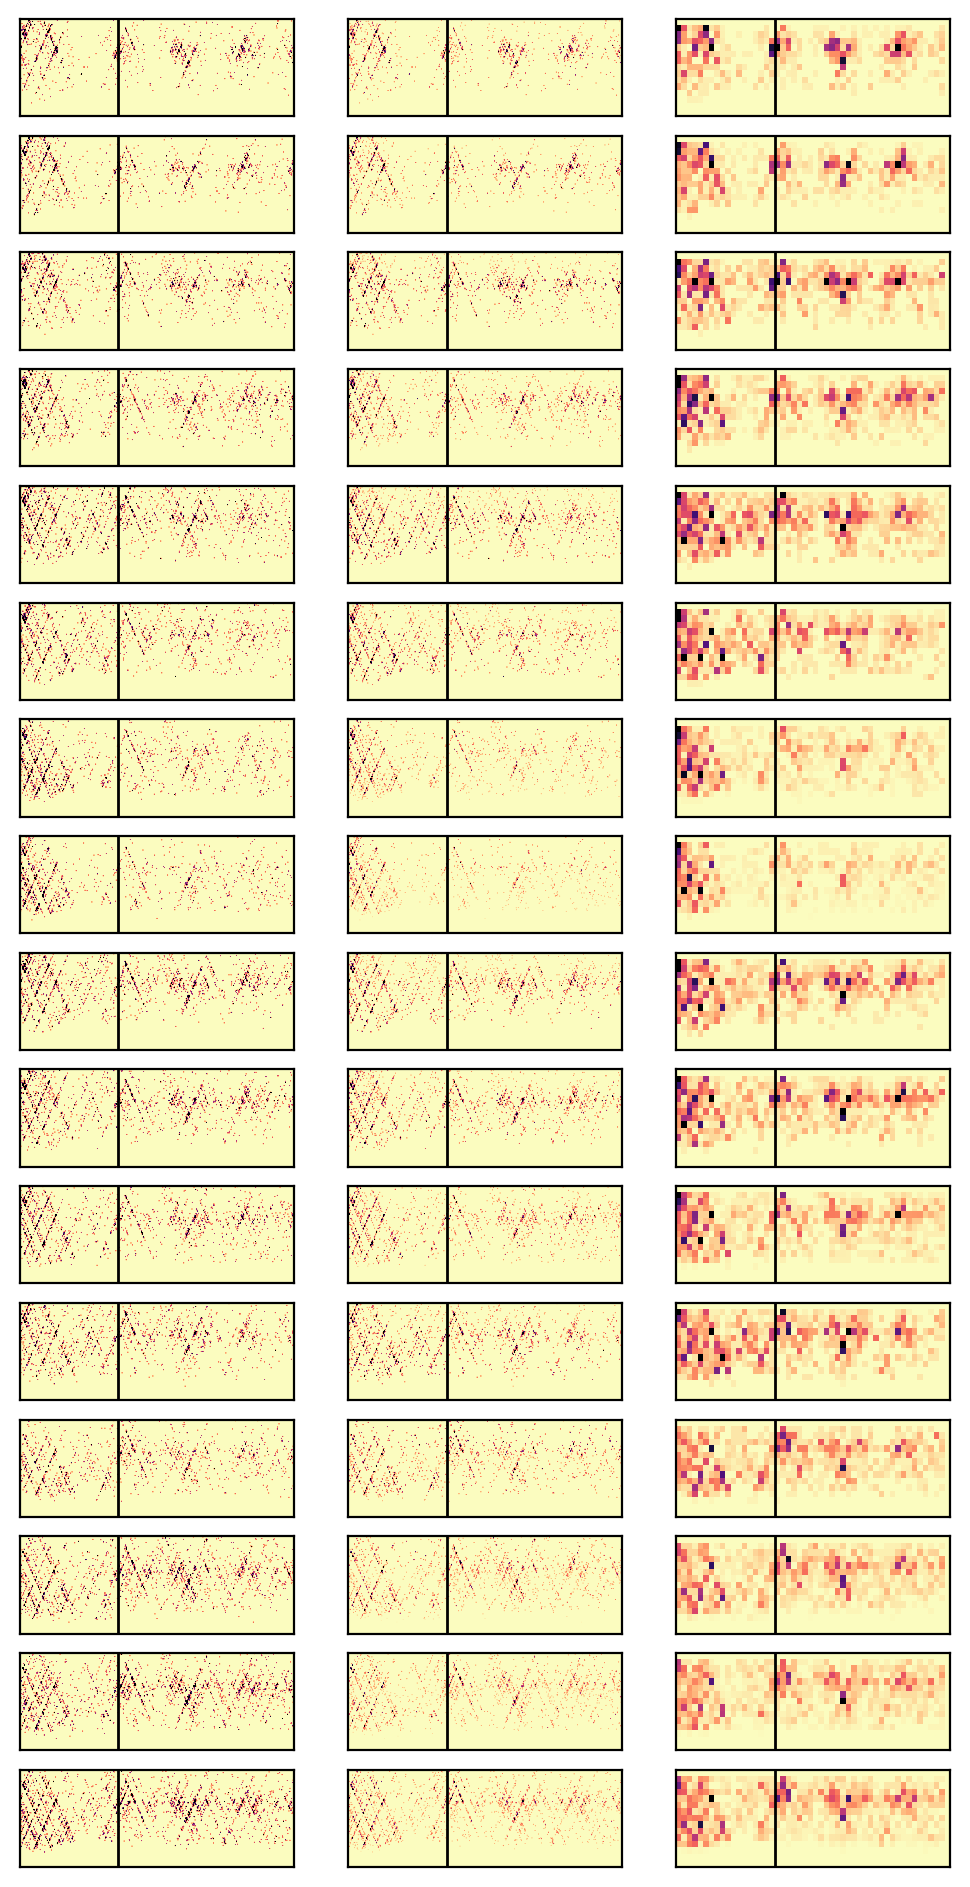

In [4]:
chromatin_model.plot_bin_comparison()

In [7]:
chromatin_model.gamma = 0.01

In [8]:
from src.deconvolve_chromatin import deconvolve_chromatin_H
import cvxpy

chromatin_model.deconvolve(solver=cvxpy.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 13 02:03:55 PM: Your problem has 170250 variables, 1 constraints, and 0 parameters.
(CVXPY) Feb 13 02:03:55 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 13 02:03:55 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 13 02:03:55 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 13 02:03:55 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 13 02:03:55 PM: Compiling problem (target solver=MOSEK).

(CVXPY) Feb 13 02:05:17 PM: 26  8.5e-03  1.7e-02  6.1e-04  3.61e-01   4.746197979e+03   4.746202865e+03   8.5e-03  30.83 
(CVXPY) Feb 13 02:05:17 PM: 27  7.7e-03  1.5e-02  5.5e-04  3.45e-01   4.738546664e+03   4.738551292e+03   7.7e-03  31.18 
(CVXPY) Feb 13 02:05:18 PM: 28  6.5e-03  1.3e-02  4.4e-04  3.37e-01   4.723624579e+03   4.723628734e+03   6.5e-03  31.54 
(CVXPY) Feb 13 02:05:18 PM: 29  5.3e-03  1.1e-02  3.5e-04  3.30e-01   4.707176311e+03   4.707179989e+03   5.3e-03  31.91 
(CVXPY) Feb 13 02:05:18 PM: 30  3.9e-03  7.8e-03  2.4e-04  3.29e-01   4.682514109e+03   4.682517135e+03   3.9e-03  32.41 
(CVXPY) Feb 13 02:05:19 PM: 31  3.3e-03  6.6e-03  2.0e-04  3.29e-01   4.668254199e+03   4.668256914e+03   3.3e-03  32.78 
(CVXPY) Feb 13 02:05:19 PM: 32  2.6e-03  5.2e-03  1.5e-04  3.34e-01   4.648253103e+03   4.648255419e+03   2.6e-03  33.21 
(CVXPY) Feb 13 02:05:20 PM: 33  2.4e-03  4.8e-03  1.4e-04  3.49e-01   4.641654561e+03   4.641656757e+03   2.4e-03  33.59 
(CVXPY) Feb 13 02:05:20 

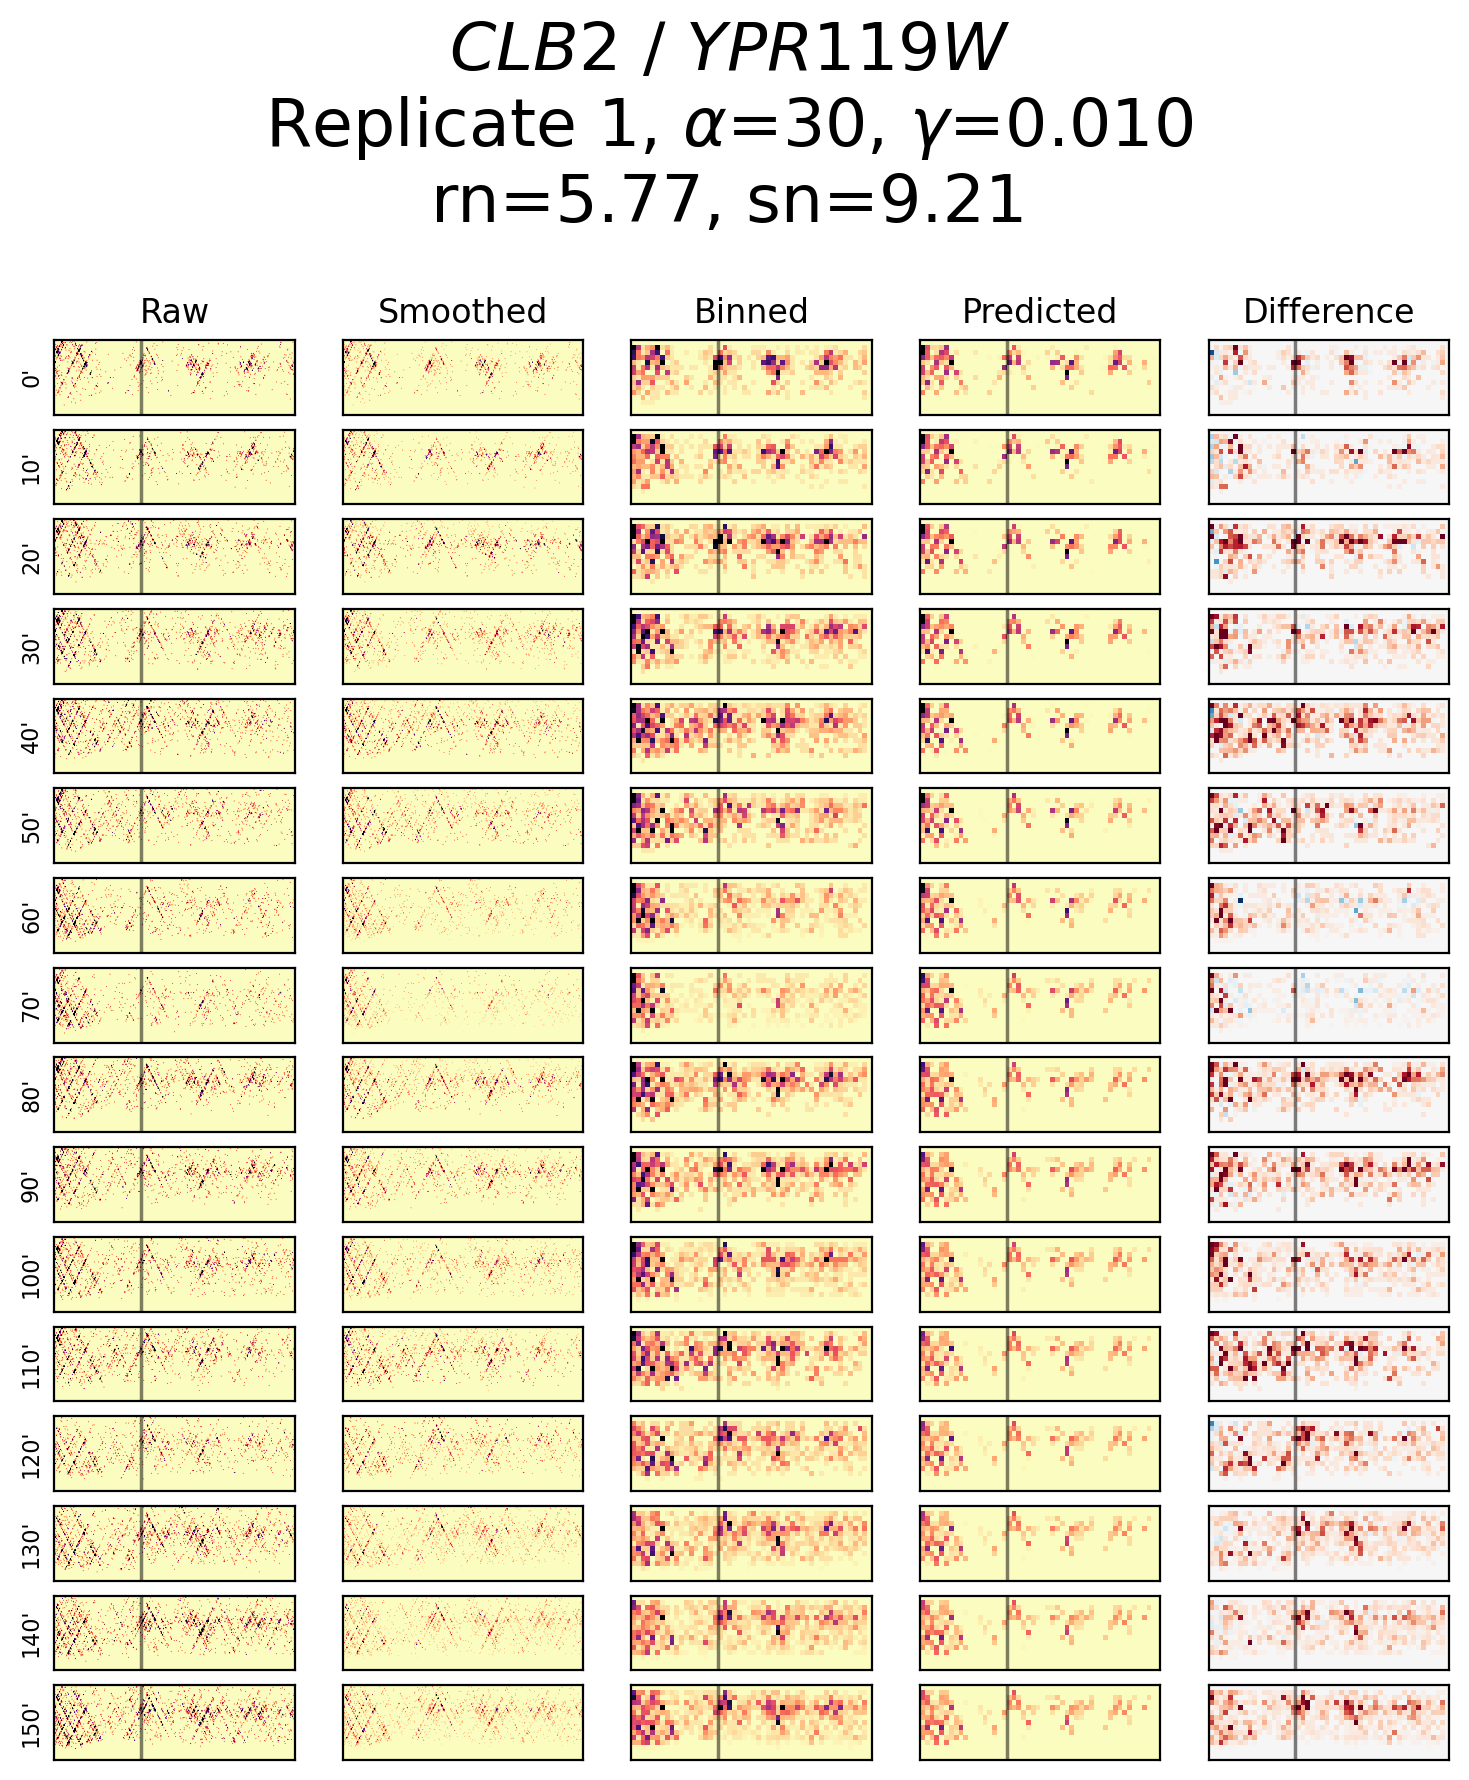

In [9]:
fig = chromatin_model.plot_prediction_comparison()

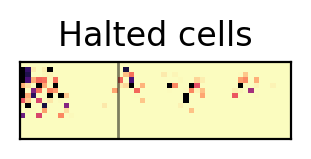

In [10]:
chromatin_model.plot_halted_f_img()

In [11]:
from src.model import Model
ge1_model = Model(config1, gene_name)

In [12]:
ge1_model.deconvolve_find_optimal_gamma()

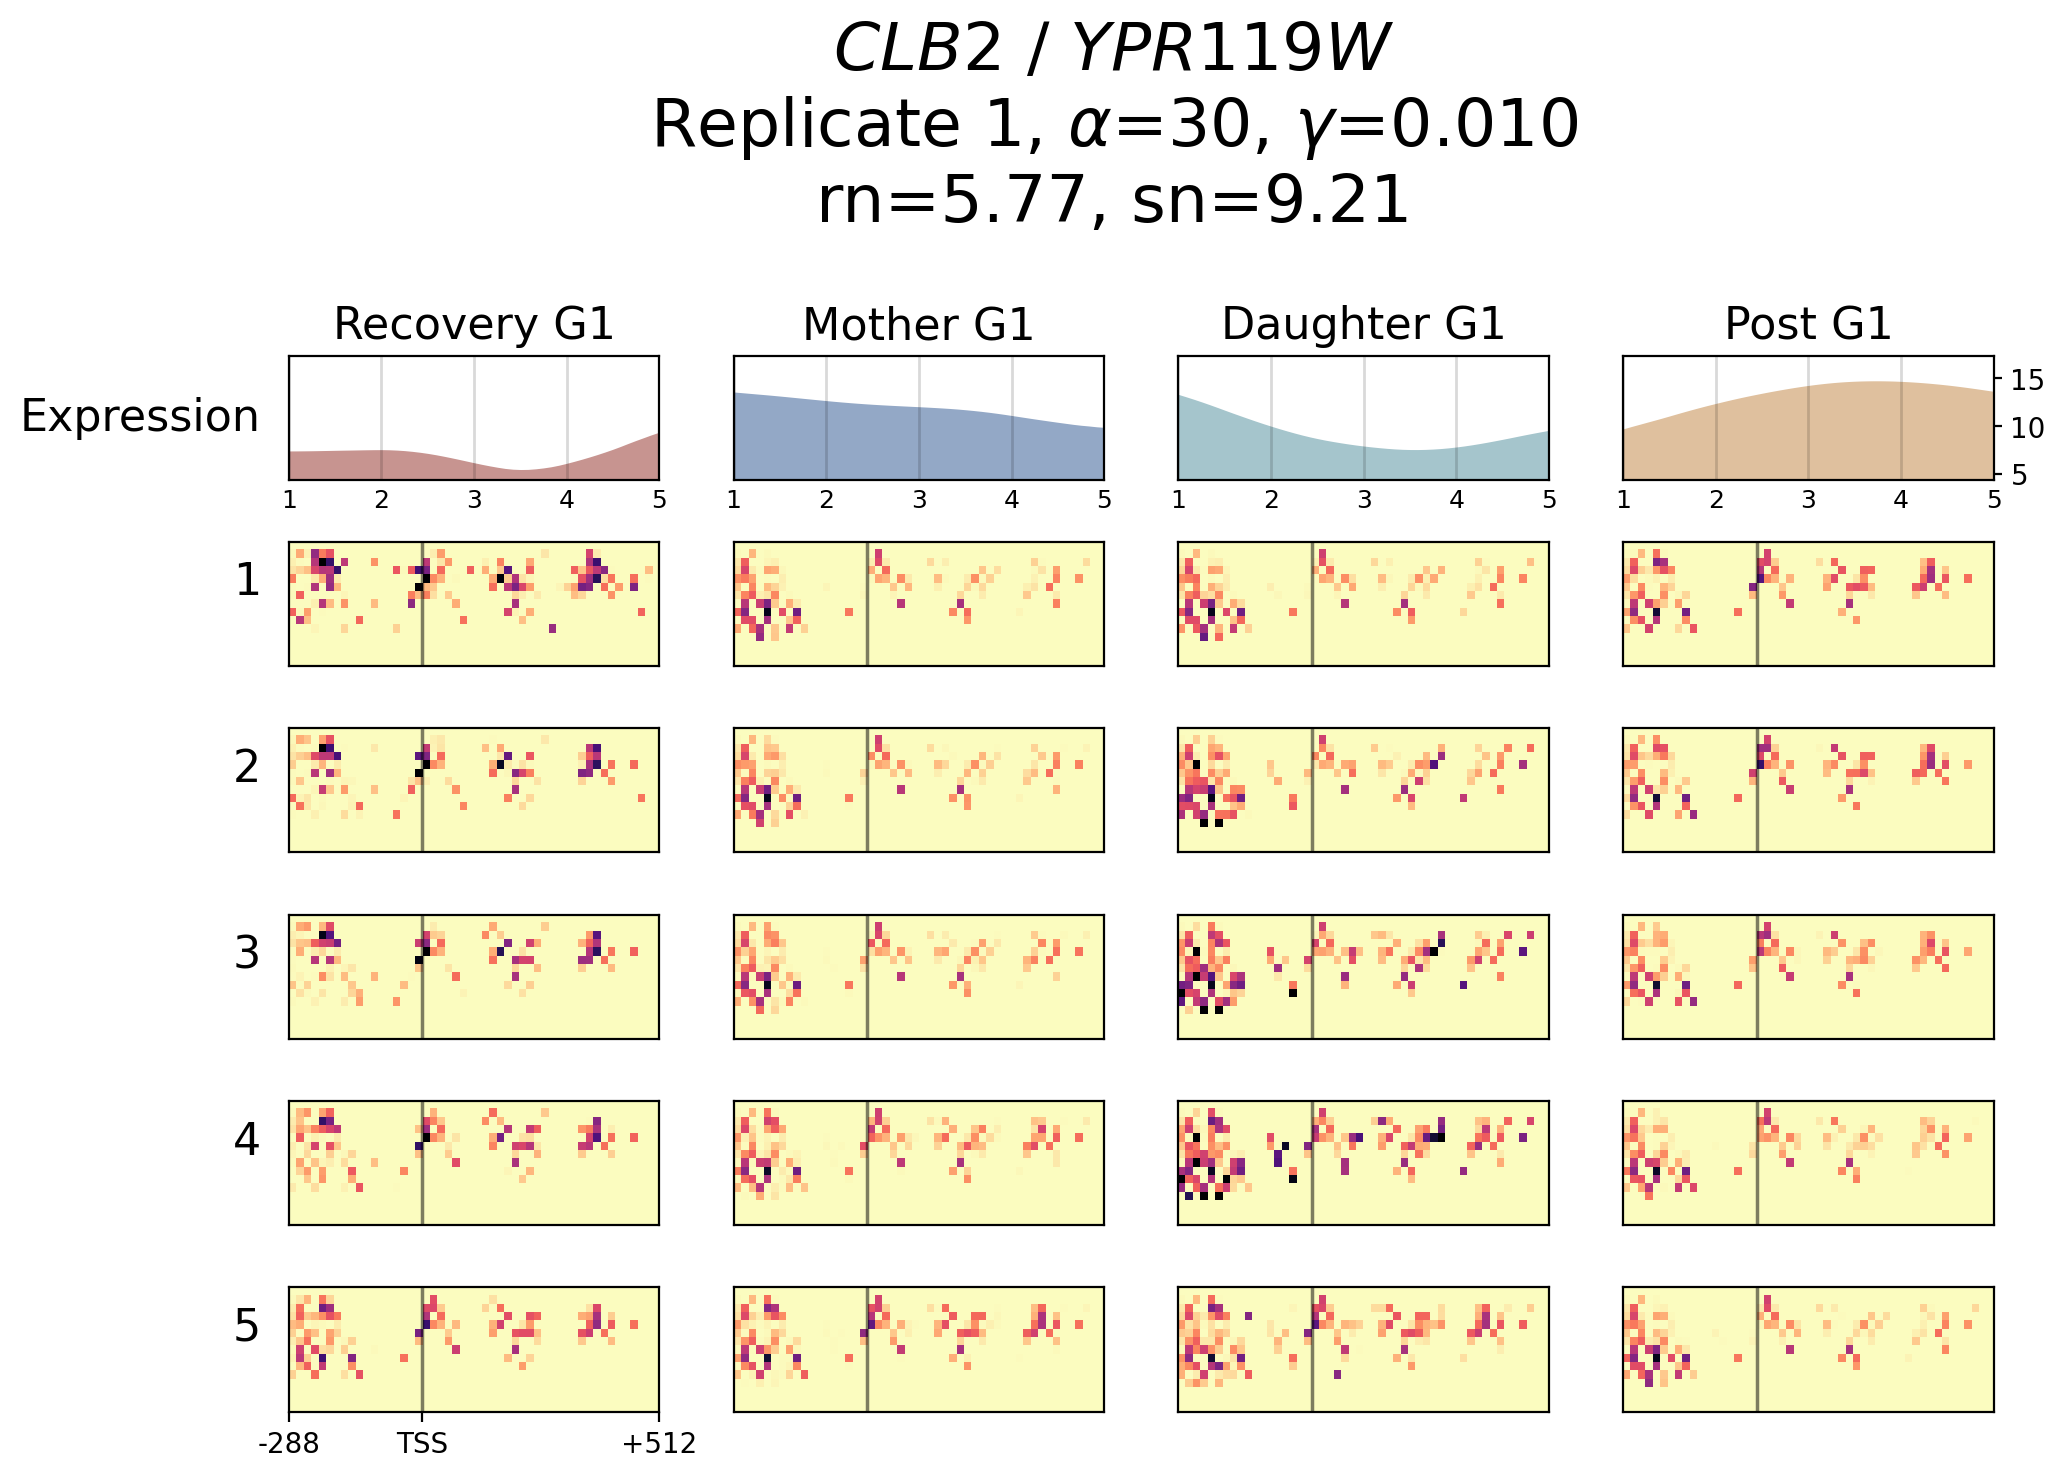

In [13]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge1_model, 
    vmax=10)

In [14]:
chromatin_model.deconvolve_find_optimal_gamma()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 5.5292
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 5.6092, rate = 1.4
  ...  search right, rn_goal = 7.7409, rate = 40.0
  ... rn range: [5.6452, 5.7664]
  ... search gamma in [0.0001 0.0100] for elbow
  ...   gm = 0.0001, rn = 5.6452, rate = 2.10, time = 00:05:13.48
  ...   gm = 0.0011, rn = 5.6596, rate = 2.36, time = 00:06:42.02
  ...   gm = 0.0021, rn = 5.6730, rate = 2.60, time = 00:08:07.96
  ...   gm = 0.0031, rn = 5.6980, rate = 3.05, time = 00:09:33.21
  ...   gm = 0.0041, rn = 5.7132, rate = 3.33, time = 00:10:59.01
  ...   gm = 0.0050, rn = 5.7244, rate = 3.53, time = 00:12:44.02
  ...   gm = 0.0060, rn = 5.7297, rate = 3.63, time = 00:14:10.14
  ...   gm = 0.0070, rn = 5.7447, rate = 3.90, time = 00:15:35.54
  ...   gm = 0.0080, rn = 5.7538, rate = 4.06, time = 00:17:02.47
  ...   gm = 0.0090, rn = 5.76

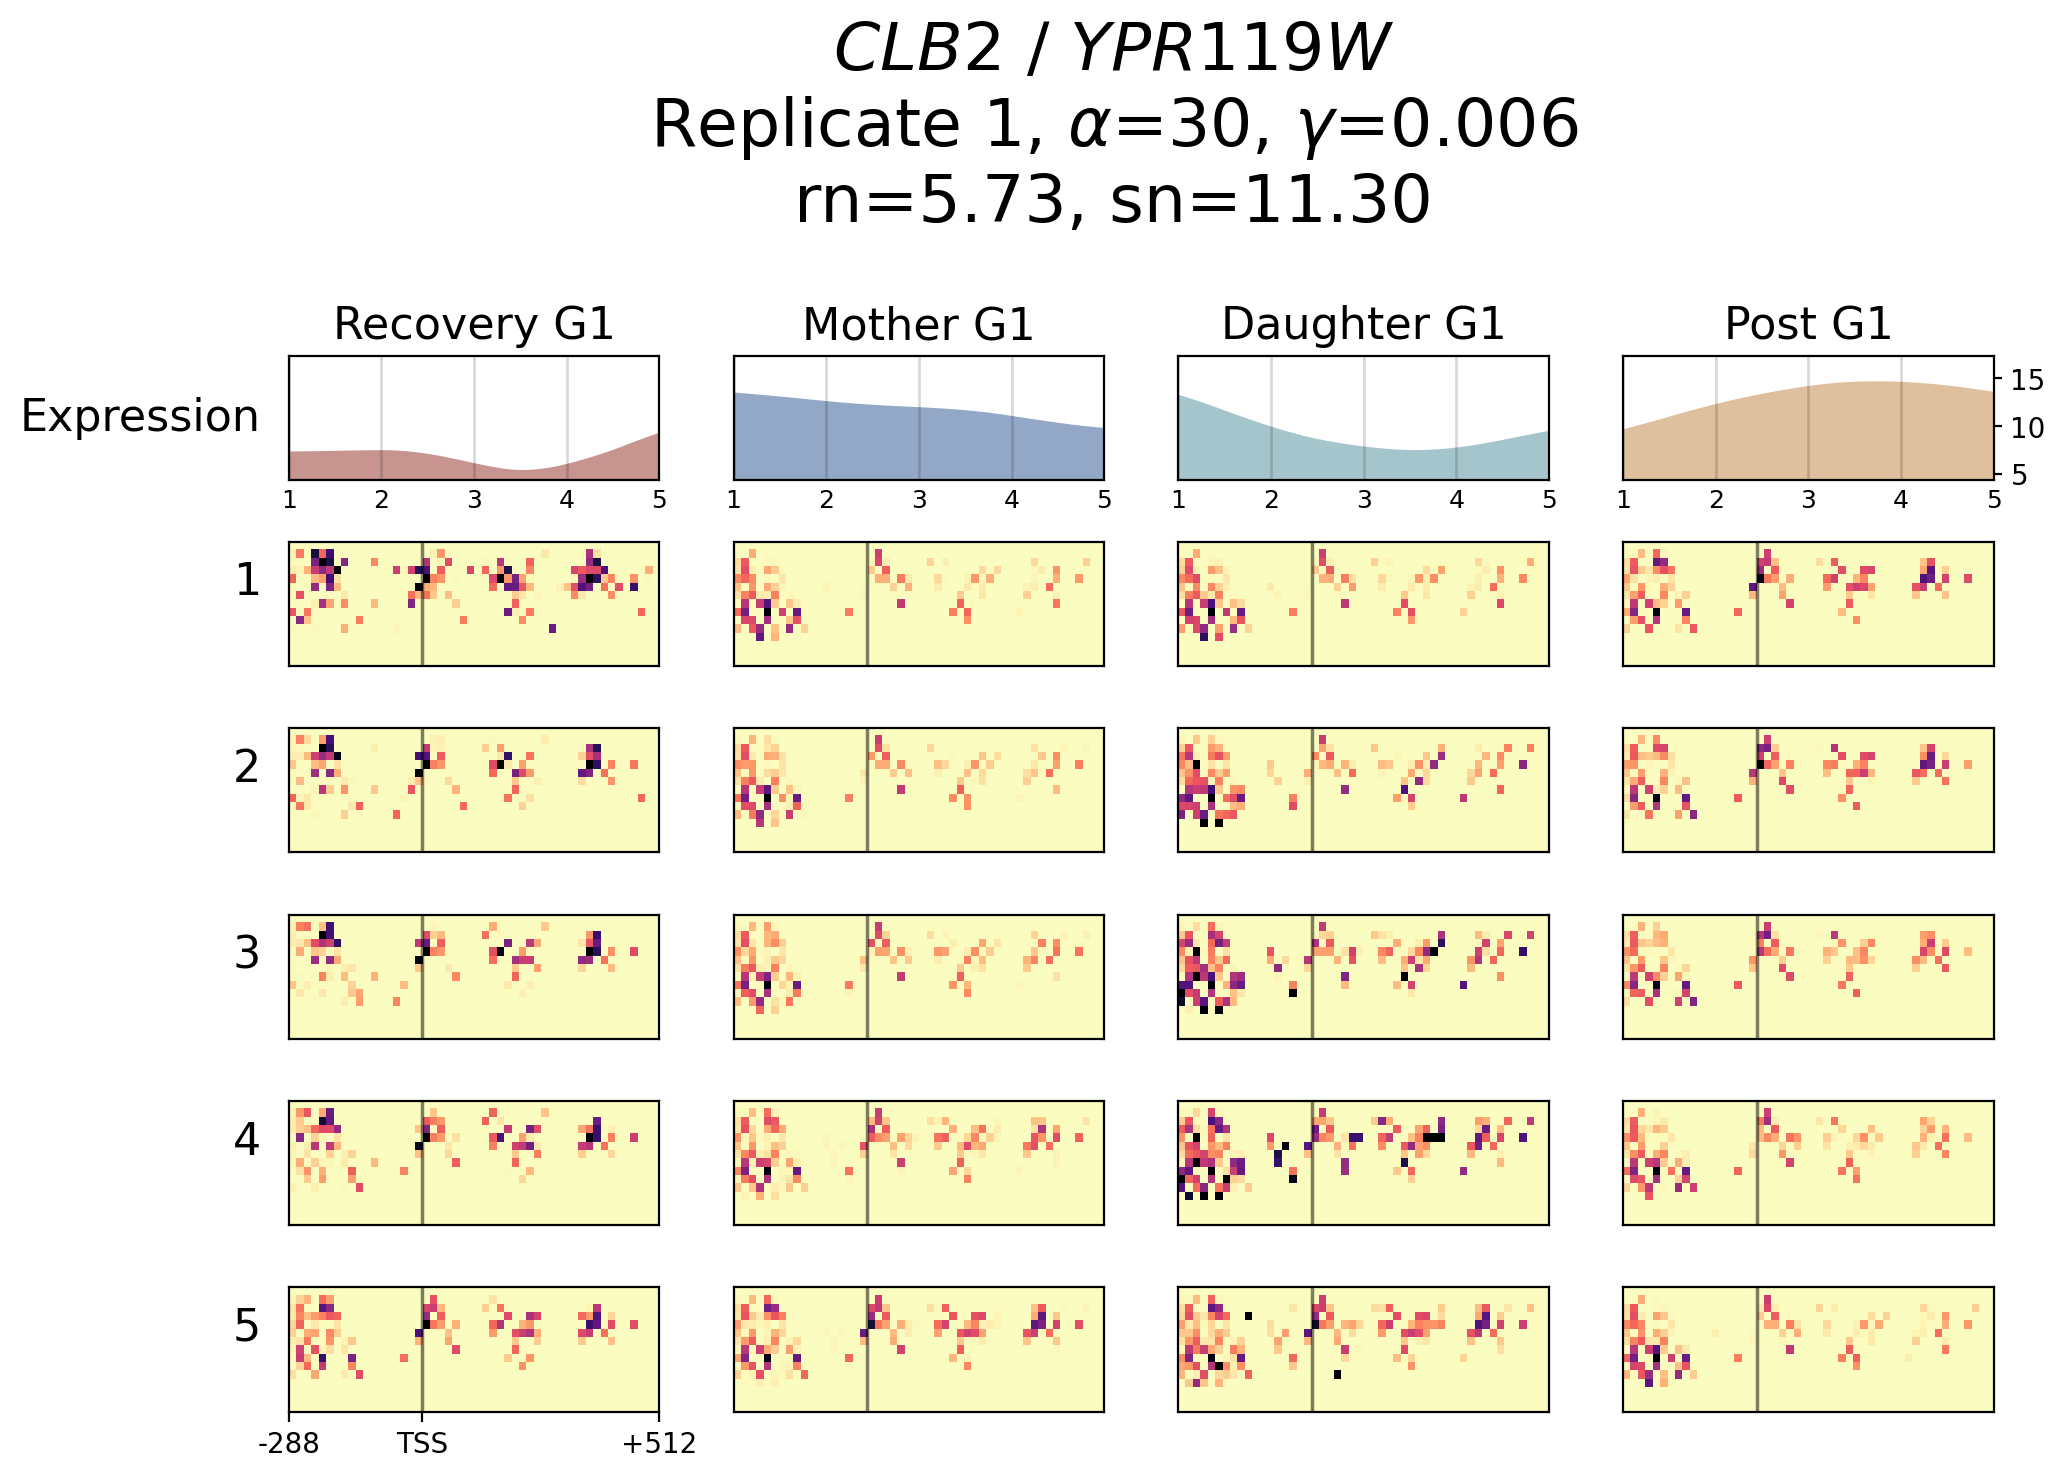

In [66]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge1_model, 
    vmax=10, smooth=False)


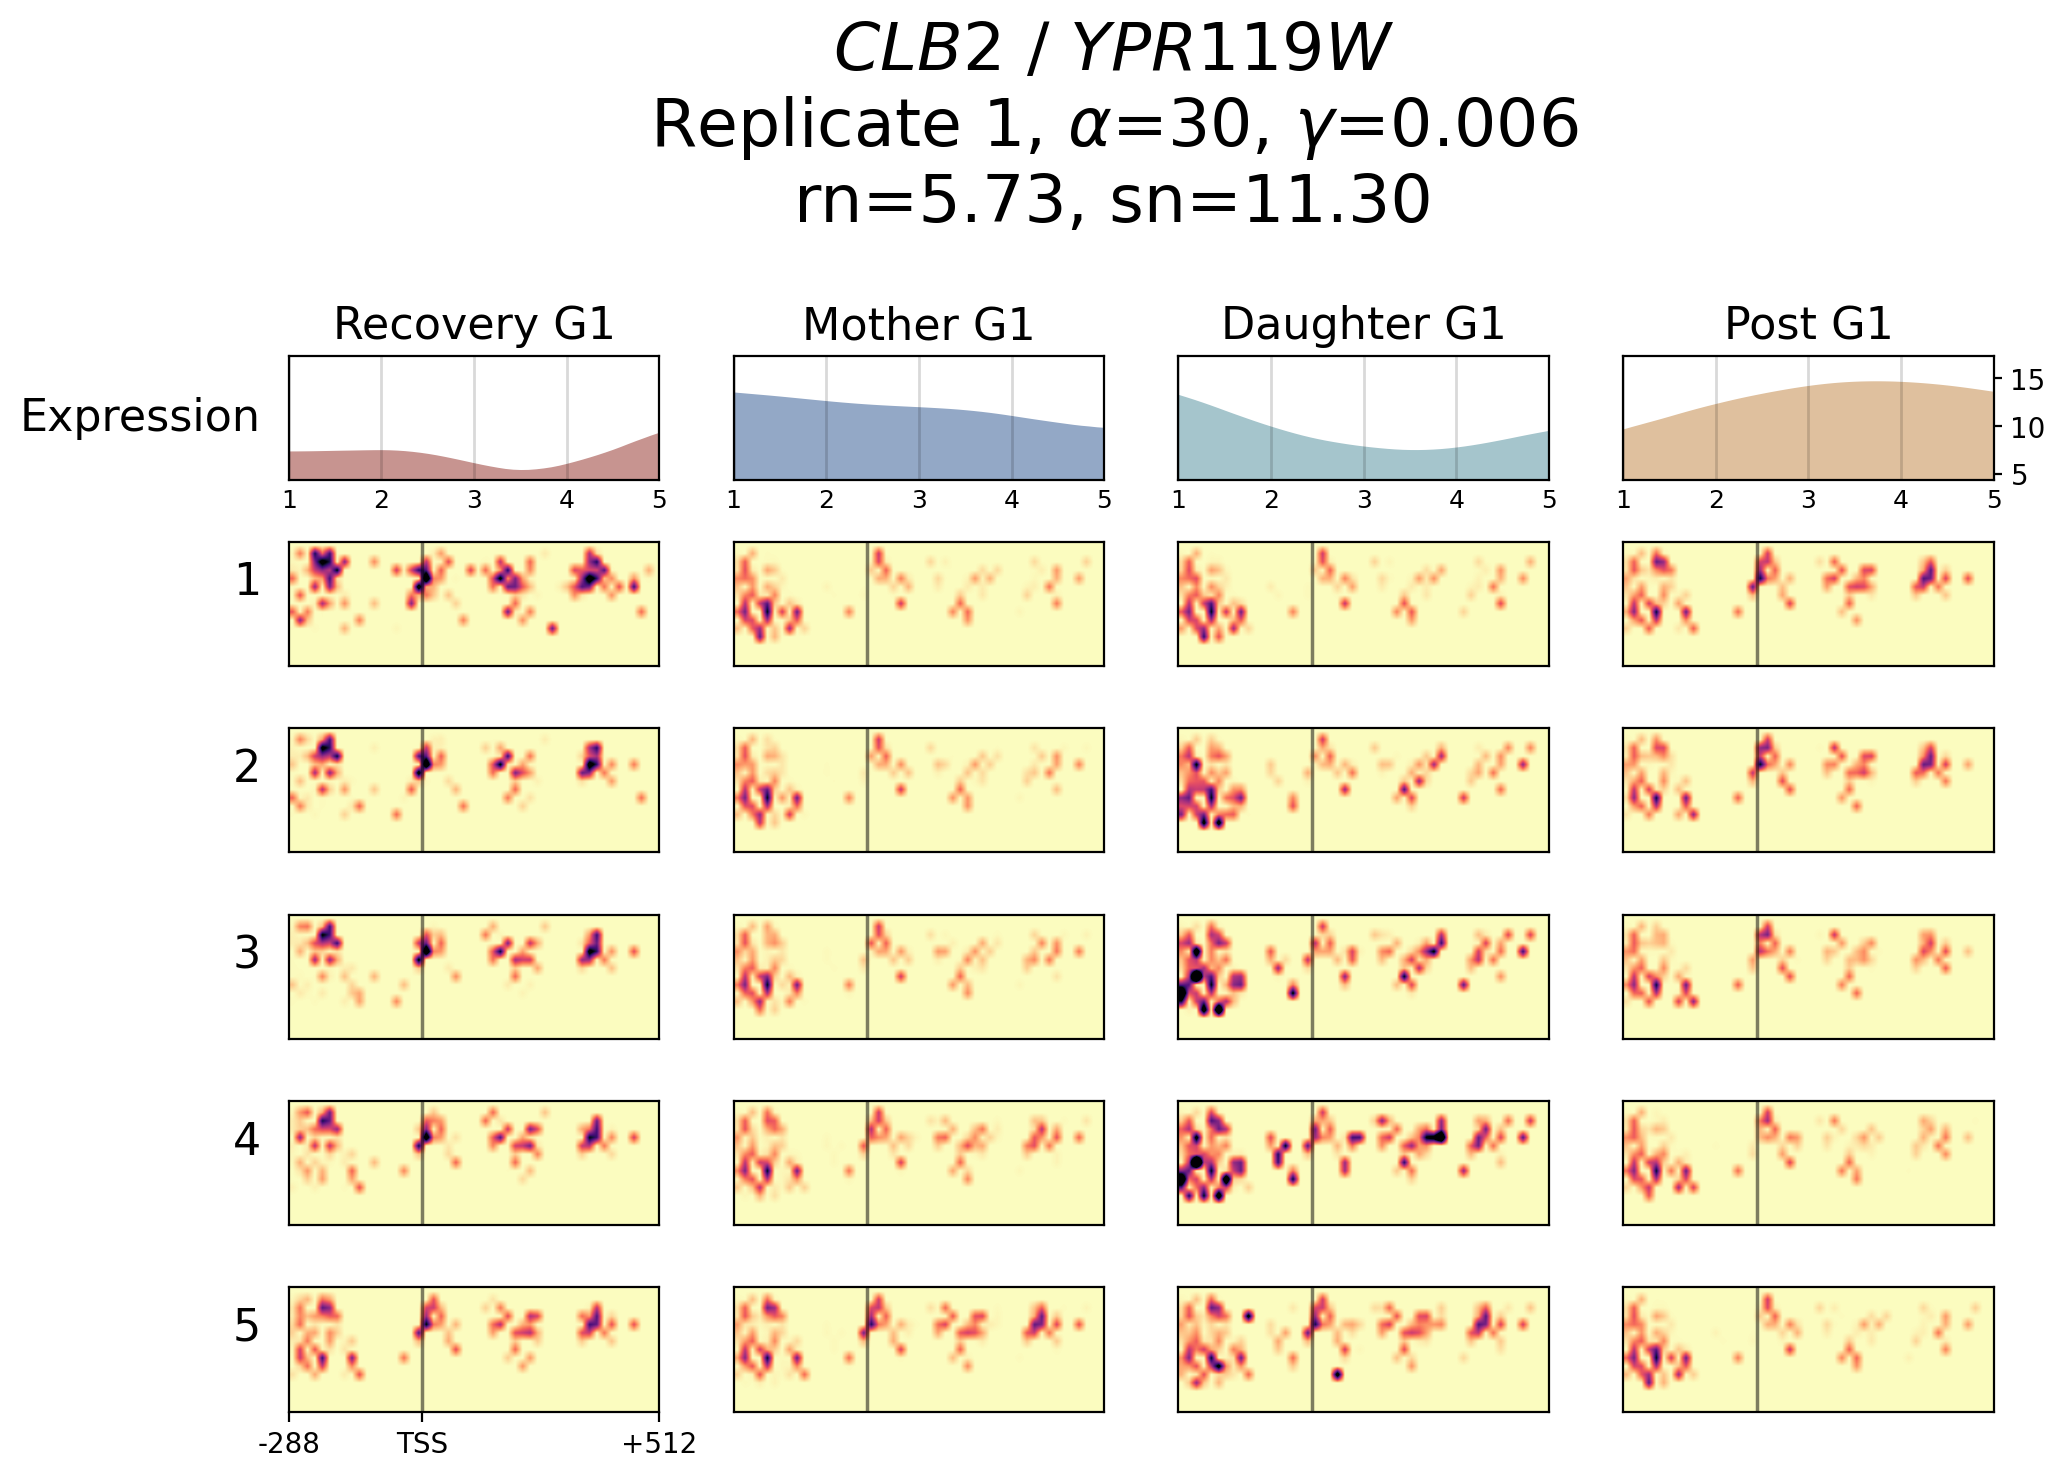

In [65]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge1_model, 
    vmax=10, smooth=True)
